# 05 - Model 3: transfer learning with MobileNetV2

MobileNetV2 trained on ImageNet (1.28 million images, 1,000 classes) is used as the feature extractor, with the same two heads as Model 2. MobileNetV2 is built from inverted residual blocks with depthwise separable convolutions, so it is small (2.26 M parameters without its classifier) but strong.

Training has two stages:

1. **Stage 1**: the backbone is frozen and only the new heads are trained (learning rate 1e-3).
2. **Stage 2, fine-tuning**: the last blocks of the backbone (from block 13 on) are unfrozen and trained together with the heads with a 10 times smaller learning rate (1e-4), so the pretrained weights only change a little.

Batch-norm layers stay frozen in both stages: they keep the ImageNet statistics instead of re-estimating them from small batches, which could destroy the pretrained features.

In [1]:
import os, sys
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
sys.path.insert(0, os.path.abspath(".."))
import tensorflow as tf
tf.get_logger().setLevel("ERROR")

import time
import keras
from keras import layers
import pandas as pd
import matplotlib.pyplot as plt

from src.config import FIGURES_DIR, IMG_SIZE, LOGS_DIR, MODELS_DIR, NUM_FRUITS, REPORTS_DIR, SEED
from src.data_pipeline import load_split, make_dataset
from src.evaluation import compute_metrics, predict
%matplotlib inline

In [2]:
RUN = "model3_mobilenet_v2"
BATCH_SIZE = 32
DROPOUT = 0.3
LOSS_WEIGHTS = {"fruit": 1.0, "freshness": 1.0}
STAGE1_EPOCHS, STAGE1_LR = 12, 1e-3
STAGE2_EPOCHS, STAGE2_LR = 25, 1e-4
FINE_TUNE_FROM = "block_13_expand"  # giai đoạn 2 train lại từ block 13 đến hết
STAGE1_CHECKPOINT = MODELS_DIR / f"{RUN}_stage1.keras"

# True: train lại cả hai giai đoạn (khoảng 2.5 giờ trên CPU); False: load model và lịch sử train đã lưu
TRAIN = False

## 1. Data

Same pipeline and labels as Model 2 (fruit + freshness).

In [3]:
keras.utils.set_random_seed(SEED)
train_ds = make_dataset("train", label_mode="multitask", batch_size=BATCH_SIZE, augment=True)
val_ds = make_dataset("val", label_mode="multitask", batch_size=BATCH_SIZE)
val_df = load_split("val")

## 2. Model

The first layer rescales the pixels to [-1, 1], the range MobileNetV2 was trained with. `input_tensor` puts the MobileNetV2 layers directly into our model, so single blocks can be unfrozen later. The backbone ends with a 7 x 7 x 1280 feature map (`out_relu`); global average pooling turns it into 1280 numbers for the two heads, which are the same as in Model 2.

In [4]:
HEADS = ["gap", "fruit_fc", "fruit_dropout", "fruit", "freshness_fc", "freshness_dropout", "freshness"]


def build_heads(features, dropout):
    pooled = layers.GlobalAveragePooling2D(name="gap")(features)
    fruit = layers.Dense(128, activation="relu", name="fruit_fc")(pooled)
    fruit = layers.Dropout(dropout, name="fruit_dropout")(fruit)
    fruit = layers.Dense(NUM_FRUITS, activation="softmax", name="fruit")(fruit)
    fresh = layers.Dense(64, activation="relu", name="freshness_fc")(pooled)
    fresh = layers.Dropout(dropout, name="freshness_dropout")(fresh)
    fresh = layers.Dense(1, activation="sigmoid", name="freshness")(fresh)
    return fruit, fresh


def build_transfer_model(dropout=0.3, weights="imagenet"):
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image")
    x = layers.Rescaling(1.0 / 127.5, offset=-1.0, name="mobilenet_v2_preprocess")(inputs)  # MobileNetV2 cần ảnh trong [-1, 1]
    # include_top=False: bỏ lớp phân loại 1000 lớp của ImageNet, chỉ giữ phần trích đặc trưng
    base = keras.applications.MobileNetV2(include_top=False, weights=weights, input_tensor=x)
    fruit, freshness = build_heads(base.output, dropout)
    model = keras.Model(inputs, {"fruit": fruit, "freshness": freshness}, name="model3_mobilenet_v2")
    set_trainable(model, None)
    return model


def set_trainable(model, fine_tune_from):
    # đóng băng backbone (trainable = False), mở lại từ layer fine_tune_from trở đi;
    # BatchNorm luôn đóng băng để giữ thống kê mean/variance học từ ImageNet
    backbone = [layer for layer in model.layers if layer.name not in HEADS + ["image", "mobilenet_v2_preprocess"]]
    if fine_tune_from is None:
        start = len(backbone)
    elif fine_tune_from == "all":
        start = 0
    else:
        start = [layer.name for layer in backbone].index(fine_tune_from)
    for i, layer in enumerate(backbone):
        layer.trainable = i >= start and not isinstance(layer, layers.BatchNormalization)
    return len(backbone) - start


def compile_model(model, learning_rate):
    # phải compile lại sau khi đổi trainable thì thay đổi mới có tác dụng
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate),
        loss={"fruit": "sparse_categorical_crossentropy", "freshness": "binary_crossentropy"},
        loss_weights=LOSS_WEIGHTS,
        metrics={"fruit": ["accuracy"], "freshness": ["accuracy", keras.metrics.AUC(name="auc")]},
    )


def trainable_params(model):
    return sum(int(keras.ops.size(w)) for w in model.trainable_weights)


model = build_transfer_model(DROPOUT, weights=None)  # chỉ để xem kiến trúc, khi train mới tải trọng số ImageNet
print(f"{len(model.layers)} layers, {model.count_params():,} parameters")
for name, start in [("stage 1", None), ("stage 2", FINE_TUNE_FROM), ("all layers", "all")]:
    unfrozen = set_trainable(model, start)
    print(f"{name:10s}: {unfrozen:3d} backbone layers unfrozen, {trainable_params(model):>9,} trainable parameters")

top = [layer.name for layer in model.layers].index("Conv_1")
pd.DataFrame([(layer.name, layer.__class__.__name__, tuple(layer.output.shape[1:]), layer.count_params())
              for layer in model.layers[top:]], columns=["layer", "type", "output shape", "parameters"])

162 layers, 2,505,033 parameters
stage 1   :   0 backbone layers unfrozen,   247,049 trainable parameters
stage 2   :  38 backbone layers unfrozen, 1,910,409 trainable parameters
all layers: 153 backbone layers unfrozen, 2,436,809 trainable parameters


,layer,type,output shape,parameters
0,Conv_1,Conv2D,"(7, 7, 1280)",409600
1,Conv_1_bn,BatchNormalization,"(7, 7, 1280)",5120
2,out_relu,ReLU,"(7, 7, 1280)",0
3,gap,GlobalAveragePooling2D,"(1280,)",0
4,freshness_fc,Dense,"(64,)",81984
5,fruit_fc,Dense,"(128,)",163968
6,freshness_dropout,Dropout,"(64,)",0
7,fruit_dropout,Dropout,"(128,)",0
8,freshness,Dense,"(1,)",65
9,fruit,Dense,"(8,)",1032


In stage 1 only the 247,049 parameters of the heads are trained.

## 3. Training

Both stages use the same callbacks as Models 1 and 2. Stage 2 starts from the best stage-1 epoch.

In [5]:
def make_callbacks(run, checkpoint, history_file):
    (LOGS_DIR / run).mkdir(parents=True, exist_ok=True)
    MODELS_DIR.mkdir(exist_ok=True)
    return [
        keras.callbacks.ModelCheckpoint(str(checkpoint), monitor="val_loss", save_best_only=True),
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3, min_lr=1e-6, verbose=1),
        keras.callbacks.CSVLogger(str(LOGS_DIR / run / history_file)),
    ]


def train_two_stages(run, train_data):
    stage1_ckpt, final_ckpt = MODELS_DIR / f"{run}_stage1.keras", MODELS_DIR / f"{run}.keras"
    # giai đoạn 1: backbone đóng băng, chỉ train hai head (lr 1e-3)
    model = build_transfer_model(DROPOUT)
    compile_model(model, STAGE1_LR)
    model.fit(train_data, validation_data=val_ds, epochs=STAGE1_EPOCHS, verbose=2,
              callbacks=make_callbacks(run, stage1_ckpt, "history_stage1.csv"))
    # giai đoạn 2 (fine-tuning): mở từ block 13, lr nhỏ hơn 10 lần (1e-4) để không phá trọng số đã học
    model = keras.models.load_model(stage1_ckpt)
    set_trainable(model, FINE_TUNE_FROM)
    compile_model(model, STAGE2_LR)
    model.fit(train_data, validation_data=val_ds, initial_epoch=STAGE1_EPOCHS, epochs=STAGE1_EPOCHS + STAGE2_EPOCHS,
              verbose=2, callbacks=make_callbacks(run, final_ckpt, "history_stage2.csv"))


def load_history(run):
    files = sorted((LOGS_DIR / run).glob("history_stage*.csv"))
    return pd.concat([pd.read_csv(f).assign(stage=int(f.stem[-1])) for f in files], ignore_index=True)


def save_to_log(row):
    path = REPORTS_DIR / "experiment_log.csv"
    log = pd.read_csv(path)
    log = pd.concat([log[log["run"] != row["run"]], pd.DataFrame([row])], ignore_index=True)
    log.to_csv(path, index=False)


if TRAIN:
    keras.utils.set_random_seed(SEED)
    t0 = time.time()
    train_two_stages(RUN, train_ds)
    minutes = (time.time() - t0) / 60

model = keras.models.load_model(MODELS_DIR / f"{RUN}.keras")
history = load_history(RUN)
for stage, h in history.groupby("stage"):
    best = h["val_loss"].idxmin()
    print(f"stage {stage}: {len(h)} epochs, best epoch {best - h.index[0] + 1}: val_loss {h.val_loss[best]:.4f}, "
          f"val fruit acc {h.val_fruit_accuracy[best]:.4f}, val freshness acc {h.val_freshness_accuracy[best]:.4f}")

stage 1: 12 epochs, best epoch 9: val_loss 0.0234, val fruit acc 0.9964, val freshness acc 0.9959
stage 2: 21 epochs, best epoch 13: val_loss 0.0022, val fruit acc 0.9995, val freshness acc 0.9995


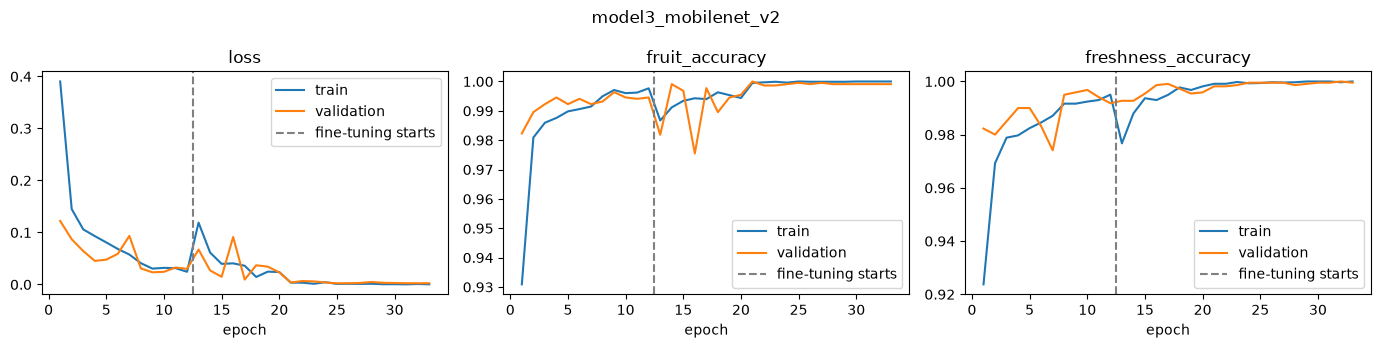

In [6]:
def plot_history(history, title):
    epochs = range(1, len(history) + 1)
    stage2 = (history["stage"] == 2).to_numpy()
    fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
    for ax, key in zip(axes, ["loss", "fruit_accuracy", "freshness_accuracy"]):
        ax.plot(epochs, history[key], label="train")
        ax.plot(epochs, history["val_" + key], label="validation")
        if 0 < stage2.argmax():
            ax.axvline(stage2.argmax() + 0.5, color="gray", linestyle="--", label="fine-tuning starts")
        ax.set_title(key)
        ax.set_xlabel("epoch")
        ax.legend()
    fig.suptitle(title)
    plt.tight_layout()
    return fig


fig = plot_history(history, RUN)
fig.savefig(FIGURES_DIR / "learning_curves" / f"{RUN}.png", dpi=150, bbox_inches="tight")

With the frozen ImageNet features alone (stage 1) both validation accuracies are already about 99.6 %. When fine-tuning starts, the loss jumps for a few epochs because the unfrozen blocks begin to change, and then it drops below the stage-1 level; the validation accuracies end close to 100 %.

## 4. Validation results

In [7]:
metrics = compute_metrics(val_df, predict(model, val_ds))
if TRAIN:
    save_to_log({"run": RUN, "model": "transfer", "augmentation": True, "fine_tune_from": FINE_TUNE_FROM,
                 "unfrozen_layers": 38, "train_minutes": round(minutes, 1),
                 **{f"val_{k}": round(v, 4) for k, v in metrics.items()}, "params": model.count_params()})
pd.Series(metrics).round(4).to_frame("validation")

,validation
fruit_accuracy,0.9995
fruit_precision,0.9995
fruit_recall,0.9996
fruit_f1,0.9995
freshness_accuracy,0.9995
freshness_precision,0.9992
freshness_recall,1.0000
freshness_f1,0.9996
freshness_macro_f1,0.9995
freshness_auc,1.0000


## 5. Ablation: how many layers to fine-tune

All runs start from the same stage-1 model (the checkpoint of the run above), so only the fine-tuning depth changes. `none` is the stage-1 model without fine-tuning.

In [8]:
DEPTHS = {  # tên run -> layer đầu tiên được mở khi fine-tune
    "model3_ft_none": None,
    "model3_ft_block16": "block_16_expand",
    RUN: FINE_TUNE_FROM,
    "model3_ft_block10": "block_10_expand",
    "model3_ft_block6": "block_6_expand",
    "model3_ft_all": "all",
}


def fine_tune(run, start):
    # chỉ chạy giai đoạn 2, tất cả bắt đầu từ cùng một model giai đoạn 1
    model = keras.models.load_model(STAGE1_CHECKPOINT)
    if start is None:
        model.save(MODELS_DIR / f"{run}.keras")
        return
    set_trainable(model, start)
    compile_model(model, STAGE2_LR)
    model.fit(train_ds, validation_data=val_ds, epochs=STAGE2_EPOCHS, verbose=2,
              callbacks=make_callbacks(run, MODELS_DIR / f"{run}.keras", "history_stage2.csv"))


arch = build_transfer_model(DROPOUT, weights=None)
rows = []
for run, start in DEPTHS.items():
    if TRAIN and run != RUN:
        keras.utils.set_random_seed(SEED)
        t0 = time.time()
        fine_tune(run, start)
        minutes = (time.time() - t0) / 60
    m = model if run == RUN else keras.models.load_model(MODELS_DIR / f"{run}.keras")
    m_metrics = metrics if run == RUN else compute_metrics(val_df, predict(m, val_ds))
    unfrozen = set_trainable(arch, start)
    if TRAIN and run != RUN:
        save_to_log({"run": run, "model": "transfer", "augmentation": True, "fine_tune_from": start or "none",
                     "unfrozen_layers": unfrozen, "train_minutes": round(minutes, 1),
                     **{f"val_{k}": round(v, 4) for k, v in m_metrics.items()}, "params": m.count_params()})
    h2 = load_history(run).query("stage == 2") if start else pd.DataFrame()
    if len(h2) and run != RUN:
        fig = plot_history(h2.reset_index(drop=True), run)
        fig.savefig(FIGURES_DIR / "learning_curves" / f"{run}.png", dpi=150, bbox_inches="tight")
        plt.close(fig)
    rows.append({"run": run, "unfrozen from": start or "none (frozen)", "unfrozen layers": unfrozen,
                 "trainable params": trainable_params(arch), "stage-2 epochs": len(h2),
                 "val joint acc": m_metrics["joint_accuracy"], "val freshness F1": m_metrics["freshness_f1"]})
pd.DataFrame(rows).set_index("run").round(4)

,unfrozen from,unfrozen layers,trainable params,stage-2 epochs,val joint acc,val freshness F1
run,,,,,,
model3_ft_none,none (frozen),0,247049,0,0.9923,0.9962
model3_ft_block16,block_16_expand,11,1126089,25,0.9991,0.9992
model3_mobilenet_v2,block_13_expand,38,1910409,21,0.9991,0.9996
model3_ft_block10,block_10_expand,64,2206857,25,0.9991,0.9992
model3_ft_block6,block_6_expand,100,2384841,18,1.0000,1.0000
model3_ft_all,all,153,2436809,20,0.9995,0.9996


Fine-tuning matters mostly for the freshness head: with the frozen backbone the validation joint accuracy is 99.2 %, every fine-tuned version reaches 99.9-100 %. On the validation set the depths differ by only one or two images, so they are compared on the test set in notebook 06. Block 13 was chosen as the main setting before this ablation was run.

## 6. Ablation: no data augmentation

Both stages again, without augmentation.

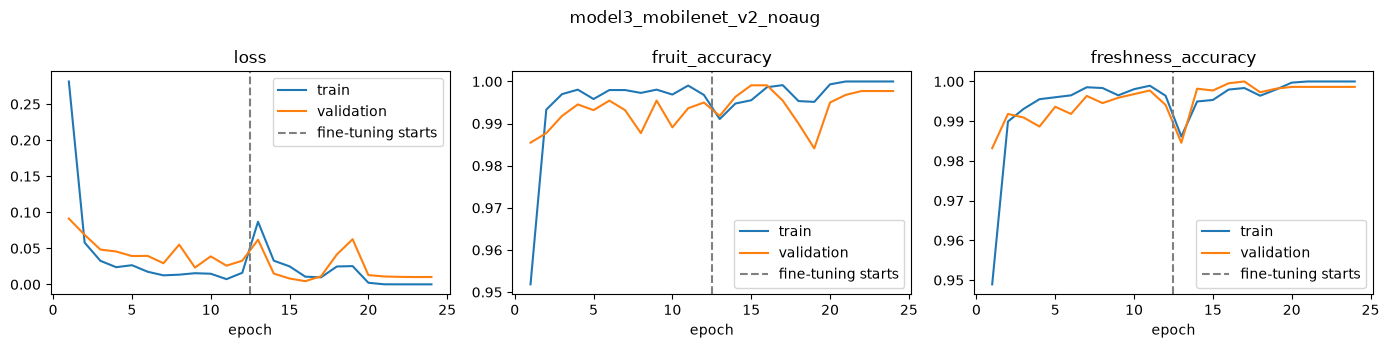

In [9]:
RUN_NOAUG = RUN + "_noaug"
if TRAIN:
    keras.utils.set_random_seed(SEED)
    t0 = time.time()
    train_two_stages(RUN_NOAUG, make_dataset("train", label_mode="multitask", batch_size=BATCH_SIZE, augment=False))
    minutes = (time.time() - t0) / 60

model_noaug = keras.models.load_model(MODELS_DIR / f"{RUN_NOAUG}.keras")
history_noaug = load_history(RUN_NOAUG)
metrics_noaug = compute_metrics(val_df, predict(model_noaug, val_ds))
if TRAIN:
    save_to_log({"run": RUN_NOAUG, "model": "transfer", "augmentation": False, "fine_tune_from": FINE_TUNE_FROM,
                 "unfrozen_layers": 38, "train_minutes": round(minutes, 1),
                 **{f"val_{k}": round(v, 4) for k, v in metrics_noaug.items()}, "params": model_noaug.count_params()})
fig = plot_history(history_noaug, RUN_NOAUG)
fig.savefig(FIGURES_DIR / "learning_curves" / f"{RUN_NOAUG}.png", dpi=150, bbox_inches="tight")

In [10]:
def summary(history, metrics):
    h2 = history.query("stage == 2")
    return {"stage-2 epochs": len(h2), "best stage-2 epoch": int(h2["val_loss"].values.argmin()) + 1,
            "val loss (best epoch)": h2["val_loss"].min(), "val joint accuracy": metrics["joint_accuracy"],
            "val fruit accuracy": metrics["fruit_accuracy"], "val freshness F1": metrics["freshness_f1"]}


pd.DataFrame({"with augmentation": summary(history, metrics),
              "without augmentation": summary(history_noaug, metrics_noaug)}).round(4)

,with augmentation,without augmentation
stage-2 epochs,21.0000,12.0000
best stage-2 epoch,13.0000,4.0000
val loss (best epoch),0.0022,0.0045
val joint accuracy,0.9991,0.9986
val fruit accuracy,0.9995,0.9991
val freshness F1,0.9996,0.9996


Without augmentation, stage 2 reaches its best validation loss after only 4 epochs and the validation results are slightly lower. The pretrained features make the model much less sensitive to augmentation than Model 1; on the test set the difference is 15 against 6 wrong images (notebook 06).